# Task 2: Stock Ticker Extraction

This notebook demonstrates the implementation of stock ticker extraction from Reuters news headlines and descriptions. The code identifies both explicit stock ticker mentions (e.g., $AAPL) and company names that can be mapped to tickers.

In [1]:
# Import required libraries
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Stock Mapping Function

First, we define a mapping of company names to their stock tickers. This helps us identify companies even when their ticker isn't explicitly mentioned.

In [2]:
def get_stock_mapping():
    """Returns a dictionary mapping company names to their stock tickers"""
    return {
        'apple': 'AAPL',
        'tesla': 'TSLA',
        'amazon': 'AMZN',
        'microsoft': 'MSFT',
        'google': 'GOOGL',
        'alphabet': 'GOOGL',
        'facebook': 'META',
        'meta': 'META',
        'netflix': 'NFLX',
        'disney': 'DIS',
        'walt disney': 'DIS',
        'twitter': 'TWTR',
        'wirecard': 'WRCDF',
        'tiktok': 'BDNCE',  # ByteDance (private company)
        'nvidia': 'NVDA',
        'intel': 'INTC',
        'amd': 'AMD',
        'boeing': 'BA',
        'coca cola': 'KO',
        'coca-cola': 'KO',
        'walmart': 'WMT',
        'goldman sachs': 'GS',
        'jpmorgan': 'JPM',
        'jp morgan': 'JPM',
        'bank of america': 'BAC',
        'morgan stanley': 'MS'
    }

## 2. Stock Extractor Class

Next, we create a class that handles the extraction of stock tickers from text. This class will:
1. Find explicit ticker mentions (e.g., $AAPL)
2. Find company name mentions and map them to tickers
3. Combine results from both headlines and descriptions

In [3]:
class StockExtractor:
    def __init__(self, df):
        self.df = df
        self.company_to_ticker = get_stock_mapping()

    def extract_stock_info(self, text):
        """Extract stock tickers and company names from text"""
        # Pattern to match stock tickers like $AAPL or (AAPL)
        ticker_pattern = r'[\$\(]([A-Z]{1,5})[\)]?'
        tickers = re.findall(ticker_pattern, text)
        
        # Look for company names in text
        text_lower = text.lower()
        companies = [
            (company, ticker) 
            for company, ticker in self.company_to_ticker.items()
            if company in text_lower
        ]
        
        return list(set(tickers)), companies

    def get_all_stock_mentions(self):
        """Get all stock mentions from headlines and descriptions"""
        stock_mentions = []
        
        for _, row in self.df.iterrows():
            # Extract stocks from both headline and description
            headline_tickers, headline_companies = self.extract_stock_info(row['Headlines'])
            desc_tickers, desc_companies = self.extract_stock_info(row['Description'])
            
            # Combine all found tickers
            all_tickers = set(
                headline_tickers + 
                [comp[1] for comp in headline_companies] +
                desc_tickers + 
                [comp[1] for comp in desc_companies]
            )
            
            # Create entries for each ticker found
            if all_tickers:
                for ticker in all_tickers:
                    stock_mentions.append({
                        'Date': row['Time'],
                        'Ticker': ticker,
                        'Headline': row['Headlines'],
                        'Description': row['Description']
                    })
        
        return pd.DataFrame(stock_mentions)

## 3. Load and Process Data

Now let's load the Reuters headlines data and extract stock mentions

In [4]:
# Load the Reuters headlines data
df = pd.read_csv('data/reuters_headlines.csv')
df['Time'] = pd.to_datetime(df['Time'], format='%b %d %Y')

# Create StockExtractor instance
extractor = StockExtractor(df)

# Get all stock mentions
mentions_df = extractor.get_all_stock_mentions()

print(f"Total stock mentions found: {len(mentions_df)}")
print(f"Unique stocks mentioned: {mentions_df['Ticker'].nunique()}")

Total stock mentions found: 8323
Unique stocks mentioned: 445


## 4. Analysis and Visualization

Let's analyze the stock mentions with some visualizations

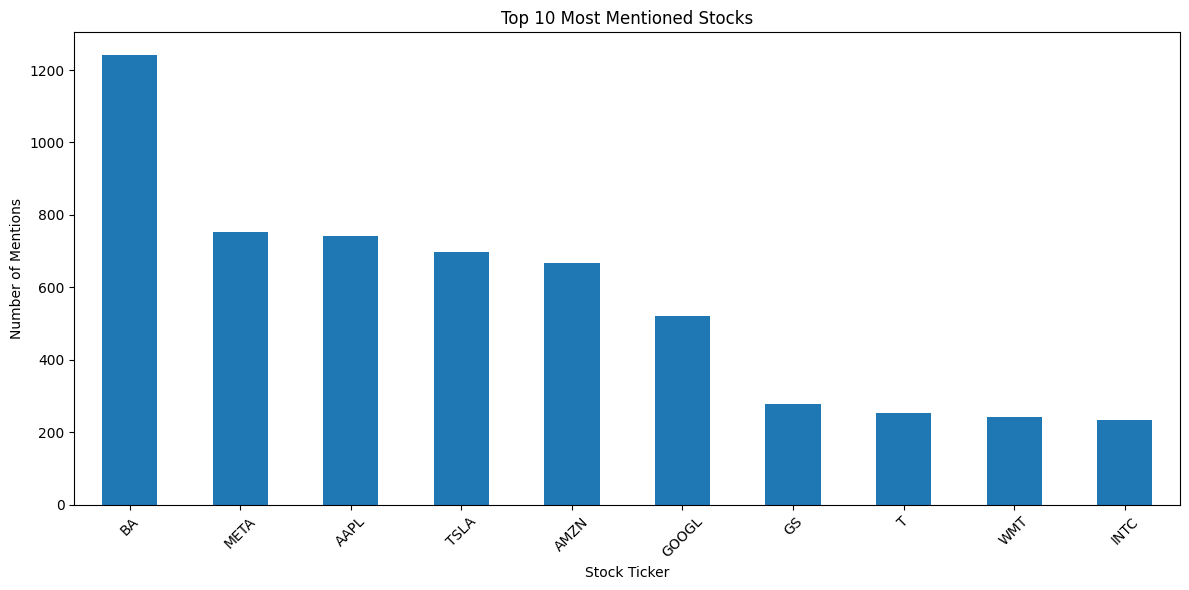

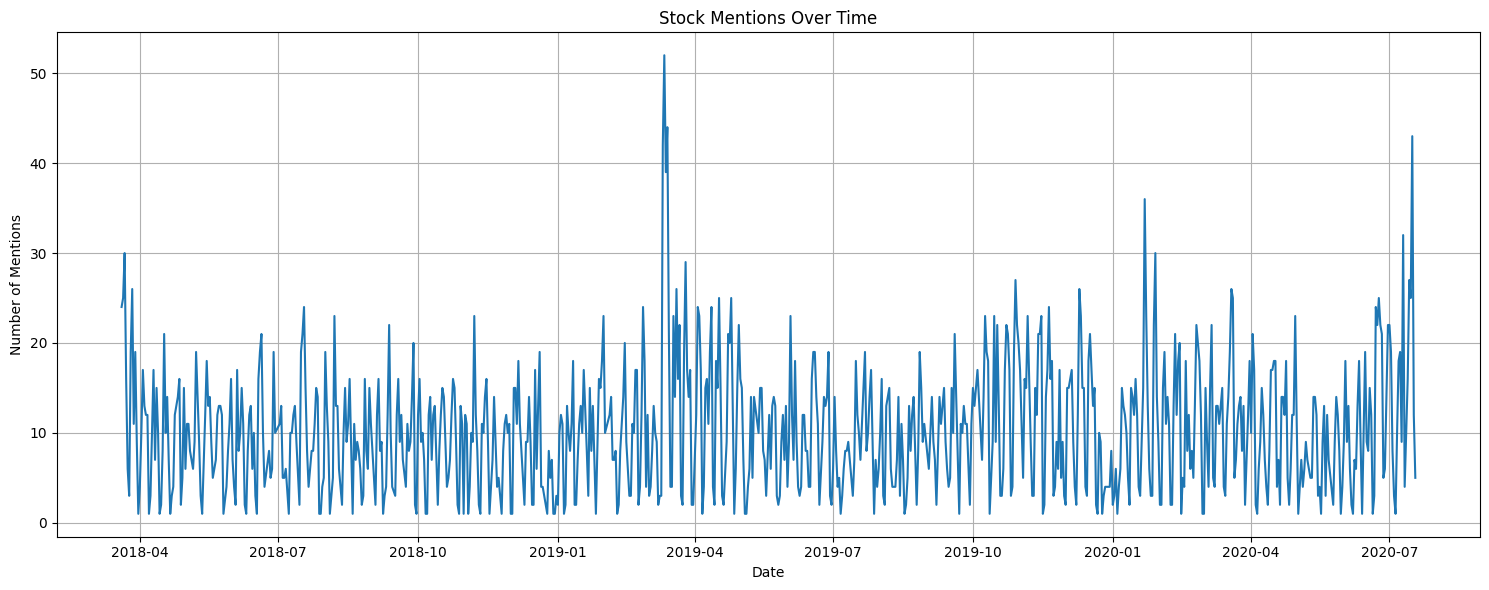


Sample of stock mentions:


,Date,Ticker,Headline,Description
0,2020-07-18,BDNCE,TikTok considers London and other locations fo...,TikTok has been in discussions with the UK gov...
1,2020-07-18,META,Disney cuts ad spending on Facebook amid growi...,Walt Disney has become the latest company to ...
2,2020-07-18,DIS,Disney cuts ad spending on Facebook amid growi...,Walt Disney has become the latest company to ...
3,2020-07-18,WRCDF,Trail of missing Wirecard executive leads to B...,Former Wirecard chief operating officer Jan M...
4,2020-07-18,TWTR,Twitter says attackers downloaded data from up...,Twitter Inc said on Saturday that hackers were...


In [5]:
# 1. Most mentioned stocks
plt.figure(figsize=(12, 6))
mentions_df['Ticker'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Most Mentioned Stocks')
plt.xlabel('Stock Ticker')
plt.ylabel('Number of Mentions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Mentions over time
daily_mentions = mentions_df.groupby('Date')['Ticker'].count().reset_index()
plt.figure(figsize=(15, 6))
plt.plot(daily_mentions['Date'], daily_mentions['Ticker'])
plt.title('Stock Mentions Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Mentions')
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Display sample of mentions
print("\nSample of stock mentions:")
display(mentions_df.head())

## 5. Save Results

Finally, let's save the extracted stock mentions to a CSV file

In [6]:
# Save to CSV
mentions_df.to_csv('stock_mentions.csv', index=False)
print("Stock mentions saved to 'stock_mentions.csv'")

Stock mentions saved to 'stock_mentions.csv'
